# YOLOv8 기반 제조 데이터 객체 탐지 실습 [프로젝트]

| 항목 | 내용 |
|---|---|
| 목표 | ① 사전학습 YOLOv8의 추론 결과 구조를 이해한다 ② 제조 현장 데이터(stamp: 신발 + 도장)로 학습·평가한다 ③ 모델·데이터 조건을 바꿔 성능 범위를 실험한다 |
| 진행 방식 | 과제 기본 코드를 순서대로 따라가며 **각 코드 아래에 의미를 정리**하고, 파트가 끝날 때마다 **🔬 개인 실험**을 수행 |
| 환경 | Windows 11 · Python 3.11 · PyTorch 2.11 (CUDA 12.8) · Ultralytics 8.4 · RTX 5060 Laptop 8GB |
| 레포 | https://github.com/hwang-ye-song/CV_YOLO |

**목차**
- Part 1. YOLOv8 확인하기 (버스 이미지) → 🔬 개인 실험 1
- Part 2. YOLOv8 학습 실습 (stamp 데이터셋) → 🔬 개인 실험 2
- 목표 기준 평가 · 개인 회고 (KPT / AAR)

# Part 1. YOLOv8 확인하기

In [1]:
!pip install ultralytics

  Using cached ultralytics-8.4.154-py3-none-any.whl.metadata (46 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached psutil-7.2.2-cp37-abi3-win_amd64.whl.metadata (22 kB)
  Using cached polars-1.44.2-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_ml_py-13.610.43-py3-none-any.whl.metadata (9.7 kB)
  Using cached ultralytics_thop-2.1.6-py3-none-any.whl.metadata (13 kB)
  Using cached ultralytics_platform-0.1.46-py3-none-any.whl.metadata (11 kB)
  Using cached polars_runtime_32-1.44.2-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
Using cached ultralytics-8.4.154-py3-none-any.whl (1.4 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached nvidia_ml_py-13.610.43-py3-none-any.whl (53 kB)
Using cached polars-1.44.2-py3-none-any.whl (865 kB)
Using cached polars_runtime_32-1.44.2-cp310-abi3-win_amd64.whl (51.3 MB)
Using cached psutil-7.2.2-cp37-abi3-win_amd64.whl (137 kB)
Using cached ultralytics_platform-0.1.46-py3-none-any.whl (78 kB)


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


📝 **설명** — YOLOv8을 만든 Ultralytics 패키지를 설치한다. 모델 정의·가중치 다운로드·학습·추론·평가 기능이 모두 들어 있다.
(이 PC에서는 프로젝트 가상환경에 미리 설치돼 있어서 `Requirement already satisfied`(이미 설치됨)로 끝난다.)

### Yolo 이해

In [2]:
from ultralytics import YOLO

📝 **설명** — `YOLO` 클래스 하나로 탐지·분류·분할 등 모든 작업을 다룬다. 어떤 작업인지는 불러오는 가중치 파일이 정한다.

In [3]:
model = YOLO('yolov8n.pt')

📝 **설명** — COCO 데이터셋(80개 클래스)으로 사전학습된 **YOLOv8 nano** 모델을 불러온다. 파일이 없으면 자동으로 받는다.
`n`(nano) < `s` < `m` < `l` < `x` 순서로 커지고, 클수록 정확하지만 느리다.

In [4]:
example_imgs = ['https://ultralytics.com/images/bus.jpg']

In [5]:
from PIL import Image
import requests
from io import BytesIO

In [6]:
response = requests.get(example_imgs[0])
img = Image.open(BytesIO(response.content))

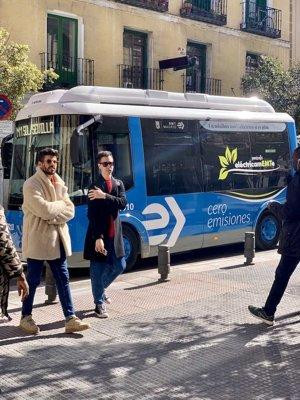

In [7]:
img.thumbnail((400,400))
img

📝 **설명** — URL의 이미지를 메모리로 받아 PIL 이미지로 연다. `thumbnail`은 **원본 비율을 유지하면서** 최대 400×400 안에 들어가게 줄인다.
화면 표시용일 뿐이고, 모델에는 원본 URL을 그대로 넘긴다.

In [8]:
results = model.predict(example_imgs[0], save=True, conf=0.25)


image 1/1 C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 17.7ms
Speed: 35.6ms preprocess, 17.7ms inference, 17.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\runs\detect\predict


📝 **설명** — 추론을 실행한다.
- `save=True`: 박스를 그린 결과 이미지를 `runs/detect/predict*/`에 저장
- `conf=0.25`: 신뢰도 0.25 미만인 박스는 버림
- 출력 로그의 `640x480`은 모델 입력 크기다. 긴 변을 640에 맞추고 비율을 유지한다.

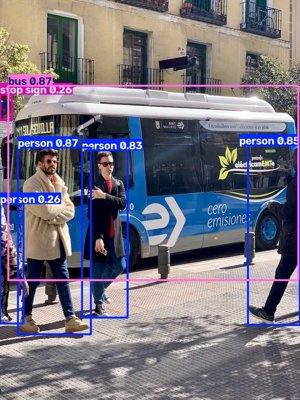

In [9]:
output_img = Image.open('./runs/detect/predict/bus.jpg')
output_img.thumbnail((400,400))
output_img

📝 **설명** — `save=True`로 저장된 결과 이미지를 열어 확인한다. 사람 4명, 버스, 정지 표지판에 박스와 이름·신뢰도가 그려져 있다.
같은 셀을 여러 번 실행하면 저장 폴더가 `predict2`, `predict3`…으로 늘어나므로, 경로를 고정하지 않으려면 `results[0].save_dir`을 쓰면 된다.

In [10]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

In [11]:
type(results)

list

In [12]:
type(results[0])

ultralytics.engine.results.Results

📝 **설명** — `predict()`는 **입력 이미지 한 장마다 `Results` 객체 하나**를 담은 리스트를 돌려준다. 이미지가 한 장이라 `results[0]`만 쓴다.
`Results` 안에는 `boxes`(탐지), `masks`(분할), `keypoints`(자세), `probs`(분류), `names`(클래스 이름표)가 있고, 탐지 모델은 `boxes`만 채워진다.

In [13]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8732, 0.8657, 0.8528, 0.8253, 0.2608, 0.2552], device='cuda:0')
data: tensor([[2.2853e+01, 2.3128e+02, 8.0501e+02, 7.5686e+02, 8.7323e-01, 5.0000e+00],
        [4.8546e+01, 3.9855e+02, 2.4534e+02, 9.0271e+02, 8.6572e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7703e+02, 8.5275e-01, 0.0000e+00],
        [2.2151e+02, 4.0580e+02, 3.4497e+02, 8.5755e+02, 8.2528e-01, 0.0000e+00],
        [0.0000e+00, 5.5052e+02, 6.3039e+01, 8.7344e+02, 2.6076e-01, 0.0000e+00],
        [5.7797e-02, 2.5446e+02, 3.2557e+01, 3.2488e+02, 2.5521e-01, 1.1000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9292, 494.0699, 782.1526, 525.5790],
        [146.9449, 650.6298, 196.7977, 504.1556],
        [739.5948, 634.6099, 140.2510, 484.8480],
        [283.2428, 631.6757, 123.4565, 451.7523],
    

📝 **설명** — `Boxes` 객체의 주요 속성
| 속성 | 내용 |
|---|---|
| `cls` | 클래스 번호 (5=bus, 0=person, 11=stop sign) |
| `conf` | 신뢰도 |
| `xyxy` / `xywh` | 픽셀 좌표 (좌상단·우하단 / 중심·크기) |
| `xyxyn` / `xywhn` | 위 좌표를 이미지 크기로 나눈 0~1 값 |
| `data` | `[x1, y1, x2, y2, conf, cls]`를 한 행에 모은 텐서 |

In [14]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

In [15]:
import yaml
import requests

url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

response = requests.get(url)
data = yaml.safe_load(response.text)

print(data)

{'path': 'coco', 'train': 'train2017.txt', 'val': 'val2017.txt', 'test': 'test-dev2017.txt', 'names': {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toi

📝 **설명** — COCO 데이터셋 설정 파일(yaml)을 읽는다. `names`에 **클래스 번호 → 이름** 표가 있어서 `cls` 숫자를 사람이 읽을 수 있는 이름으로 바꿀 때 쓴다.
(과제 원본의 `import requests=`는 문법 오류라서 `import requests`로 고쳤다.)

In [16]:
results[0].boxes.conf

tensor([0.8732, 0.8657, 0.8528, 0.8253, 0.2608, 0.2552], device='cuda:0')

📝 **설명** — 6개 박스의 신뢰도. 버스·사람 3명은 0.8 이상으로 확실하고, 가장자리에 잘린 사람과 정지 표지판은 0.26 정도로 애매하다.

In [17]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8732, 0.8657, 0.8528, 0.8253, 0.2608, 0.2552], device='cuda:0')
data: tensor([[2.2853e+01, 2.3128e+02, 8.0501e+02, 7.5686e+02, 8.7323e-01, 5.0000e+00],
        [4.8546e+01, 3.9855e+02, 2.4534e+02, 9.0271e+02, 8.6572e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7703e+02, 8.5275e-01, 0.0000e+00],
        [2.2151e+02, 4.0580e+02, 3.4497e+02, 8.5755e+02, 8.2528e-01, 0.0000e+00],
        [0.0000e+00, 5.5052e+02, 6.3039e+01, 8.7344e+02, 2.6076e-01, 0.0000e+00],
        [5.7797e-02, 2.5446e+02, 3.2557e+01, 3.2488e+02, 2.5521e-01, 1.1000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9292, 494.0699, 782.1526, 525.5790],
        [146.9449, 650.6298, 196.7977, 504.1556],
        [739.5948, 634.6099, 140.2510, 484.8480],
        [283.2428, 631.6757, 123.4565, 451.7523],
    

In [18]:
img.size

(300, 400)

📝 **설명** — `img`는 위에서 `thumbnail`로 줄였기 때문에 **(300, 400)** 이다. 박스 좌표는 원본(810×1080) 기준이므로, 정규화를 직접 계산하려면 원본 크기가 필요하다 → 아래에서 원본을 다시 받는다.
PIL의 `size`는 **(너비, 높이)** 순서라는 점도 주의.

In [19]:
results[0].boxes.xywh

tensor([[413.9292, 494.0699, 782.1526, 525.5790],
        [146.9449, 650.6298, 196.7977, 504.1556],
        [739.5948, 634.6099, 140.2510, 484.8480],
        [283.2428, 631.6757, 123.4565, 451.7523],
        [ 31.5197, 711.9839,  63.0394, 322.9200],
        [ 16.3075, 289.6674,  32.4993,  70.4186]], device='cuda:0')

In [20]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]], device='cuda:0')

In [21]:
import cv2
import requests
import numpy as np
from PIL import Image
from io import BytesIO

img_url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)
height, width = img_np.shape[:2]

In [22]:
height, width

(1080, 810)

📝 **설명** — NumPy 배열의 `shape`는 **(높이, 너비, 채널)** 순서다. 원본은 1080×810.

In [23]:
bbox1 = results[0].boxes.xywh[0]
bbox1

tensor([413.9292, 494.0699, 782.1526, 525.5790], device='cuda:0')

In [24]:
bbox1[0]/width, bbox1[1]/height, bbox1[2]/width, bbox1[3]/height

(tensor(0.5110, device='cuda:0'),
 tensor(0.4575, device='cuda:0'),
 tensor(0.9656, device='cuda:0'),
 tensor(0.4866, device='cuda:0'))

In [25]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]], device='cuda:0')

📝 **설명** — 첫 번째 박스(버스)의 `xywh`를 원본 너비·높이로 직접 나눈 값이 `xywhn[0]`과 정확히 같다.
→ **`n`이 붙은 좌표 = 원본 크기로 나눈 비율**이다. 해상도와 무관해서 YOLO 학습 라벨(txt)도 이 `xywhn` 형식을 쓴다.

In [26]:
bbox2 = results[0].boxes.xyxy[0]
bbox2

tensor([ 22.8529, 231.2805, 805.0055, 756.8594], device='cuda:0')

In [27]:
bbox2[0]/width, bbox2[1]/height, bbox2[2]/width, bbox2[3]/height

(tensor(0.0282, device='cuda:0'),
 tensor(0.2141, device='cuda:0'),
 tensor(0.9938, device='cuda:0'),
 tensor(0.7008, device='cuda:0'))

In [28]:
results[0].boxes.xyxyn[0]

tensor([0.0282, 0.2141, 0.9938, 0.7008], device='cuda:0')

📝 **설명** — `xyxy`도 같은 방식으로 정규화하면 `xyxyn`과 일치한다. `xyxy`는 OpenCV로 사각형을 그릴 때 그대로 쓸 수 있어서 시각화에 편하다.

### 시각화

In [29]:
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = np.array(Image.open(BytesIO(response.content)).convert("RGB"))
h, w = img.shape[:2]
img_copy = img.copy()

In [30]:
xyxy_coordinate = results[0].boxes.xyxy.cpu().numpy()

In [31]:
xyxy_coordinate

array([[     22.853,      231.28,      805.01,      756.86],
       [     48.546,      398.55,      245.34,      902.71],
       [     669.47,      392.19,      809.72,      877.03],
       [     221.51,       405.8,      344.97,      857.55],
       [          0,      550.52,      63.039,      873.44],
       [   0.057797,      254.46,      32.557,      324.88]], dtype=float32)

📝 **설명** — GPU에 있는 텐서를 `.cpu().numpy()`로 NumPy 배열로 옮긴다. OpenCV·matplotlib은 GPU 텐서를 직접 다루지 못한다.

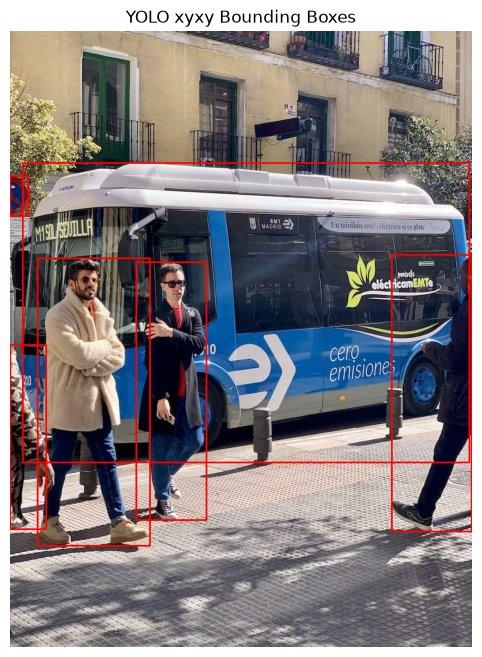

In [32]:
import matplotlib.pyplot as plt

for box in xyxy_coordinate:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=2)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("YOLO xyxy Bounding Boxes")
plt.axis("off")
plt.show()

📝 **설명** — 모든 박스를 빨간 사각형으로 직접 그렸다. `cv2.rectangle`은 정수 좌표가 필요해서 `int`로 바꾼다.
이미지를 RGB로 읽었으므로 `(255, 0, 0)`이 빨강이다. (OpenCV 기본인 BGR로 읽었다면 파랑이 된다.)

In [33]:
results[0].boxes.data

tensor([[2.2853e+01, 2.3128e+02, 8.0501e+02, 7.5686e+02, 8.7323e-01, 5.0000e+00],
        [4.8546e+01, 3.9855e+02, 2.4534e+02, 9.0271e+02, 8.6572e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7703e+02, 8.5275e-01, 0.0000e+00],
        [2.2151e+02, 4.0580e+02, 3.4497e+02, 8.5755e+02, 8.2528e-01, 0.0000e+00],
        [0.0000e+00, 5.5052e+02, 6.3039e+01, 8.7344e+02, 2.6076e-01, 0.0000e+00],
        [5.7797e-02, 2.5446e+02, 3.2557e+01, 3.2488e+02, 2.5521e-01, 1.1000e+01]], device='cuda:0')

In [34]:
det = results[0].boxes.data.cpu().numpy()

In [35]:
type(det)

numpy.ndarray

In [36]:
type(det)

numpy.ndarray

In [37]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

# URL에서 YAML 텍스트 불러오기
response = requests.get(url)
yaml_content = response.text

# YAML 파싱
parsed = yaml.safe_load(yaml_content)

# 클래스 이름 추출
class_names = parsed['names']

In [38]:
class_names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

데이터 클래스를 확인하였다
-> 시나리오 기반으로 생각할때는 필요없는 클래스들이 많아보인다
=> 액션

📝 **설명** — COCO 80개 클래스 중 제조 현장 시나리오에 필요한 것은 거의 없다. 필요한 클래스만 **걸러서** 쓰거나, 원하는 대상을 **새로 학습**해야 한다.
아래는 먼저 "걸러 쓰기"를 해본다.

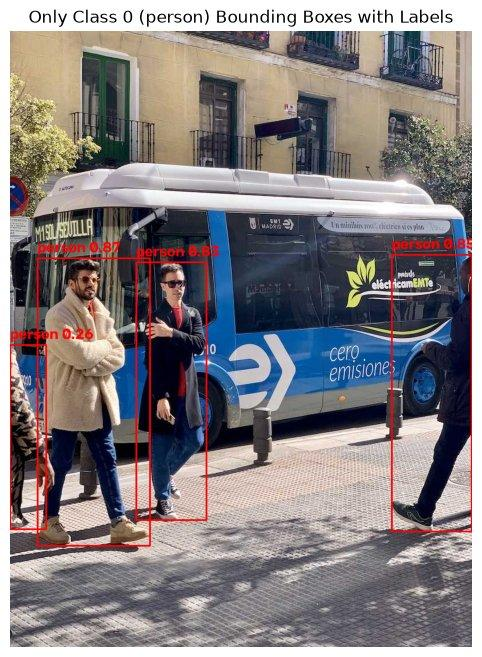

In [39]:
img_copy = img_np.copy()


for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == 0:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        label = f"{class_names[int(cls)]} {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (255, 0, 0), 2)


plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("Only Class 0 (person) Bounding Boxes with Labels")
plt.axis("off")
plt.show()

반쯤 가려진 사람도 잘 찾았다.
버스는 찾지않아도 되니까 결과 시각화에서 제외한다.
목표(시나리오)에 따르면 표지판에 대해서 찾을 수 있어야한다. -> 어떤 작업이 필요한가?

📝 **설명** — `boxes.data`의 각 행을 `x1, y1, x2, y2, conf, cls`로 풀고, `cls == 0`(person)인 박스만 이름·신뢰도와 함께 그렸다.
왼쪽 끝의 반쯤 잘린 사람도 0.26으로 잡혔다. 반면 표지판(stop sign)은 신뢰도가 낮고, COCO에 없는 표지판은 아예 찾을 수 없다.
→ **찾고 싶은 대상을 라벨링한 데이터로 추가 학습(파인튜닝)** 이 필요하다 (Part 2).

In [40]:
import os
bus_class_id = [k for k, v in class_names.items() if v == 'bus'][0]
os.makedirs("bus_crops", exist_ok=True)

count = 0
for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == bus_class_id:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cropped = img_np[y1:y2, x1:x2]
        save_path = f"bus_crops/bus_crop_{count}.jpg"
        cv2.imwrite(save_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))
        print(f"버스 {count}번 잘라서 저장: {save_path}")
        count += 1

버스 0번 잘라서 저장: bus_crops/bus_crop_0.jpg


📝 **설명** — 클래스 이름에서 `bus`의 번호(5)를 찾아, 버스 박스 영역만 배열 슬라이싱(`img_np[y1:y2, x1:x2]`)으로 잘라 저장한다.
`cv2.imwrite`는 BGR 순서로 저장하므로 RGB → BGR 변환이 필요하다.
제조 라인에서는 이렇게 **탐지 → 잘라내기 → 정밀 검사**의 2단계로 많이 쓴다.

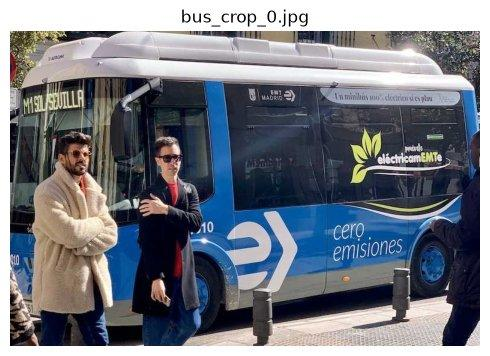

In [41]:
import os
import cv2
import matplotlib.pyplot as plt

crop_folder = "bus_crops"

image_files = sorted([f for f in os.listdir(crop_folder) if f.endswith(".jpg")])

num_images = len(image_files)
plt.figure(figsize=(5 * num_images, 5))

for i, filename in enumerate(image_files):
    img_path = os.path.join(crop_folder, filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV는 BGR로 불러오기 때문에 RGB로 변환

    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()

📝 **설명** — 저장한 crop 이미지를 다시 읽어 확인한다. 버스 한 대가 잘려 나왔다.

---
## 🔬 개인 실험 1 — 사전학습 모델을 더 알아보기

기본 실습에서 생긴 질문을 직접 확인한다.
1. **신뢰도 임계값(conf)** 을 바꾸면 탐지 결과가 어떻게 달라지나?
2. **추가 샘플 이미지**에서도 잘 되나? **모델 크기·버전**(YOLOv8n / YOLOv8s / YOLO11n)에 따라 무엇이 달라지나?
3. **NMS의 IoU 임계값**은 겹친 박스에 어떤 영향을 주나?

📝 **용어 먼저 정리**
| 용어 | 뜻 |
|---|---|
| **신뢰도(conf)** | 모델이 "여기에 이 물체가 있다"고 확신하는 정도(0~1). 기준값보다 낮은 박스는 버린다. |
| **모델 크기** | `n`(nano) < `s`(small) < `m` < `l` < `x`. 클수록 파라미터가 많아 정확할 수 있지만 느리다. |
| **모델 버전** | YOLOv8 → YOLO11처럼 숫자가 클수록 최신 구조다. |
| **IoU** | 두 박스가 얼마나 겹치는지(0~1). 완전히 겹치면 1, 안 겹치면 0. |
| **NMS** | 물체 하나에 겹쳐 나온 박스 중 **하나만 남기는** 정리 단계. IoU가 기준값보다 큰 박스를 중복으로 보고 지운다. (자세한 과정은 1-3) |

모델 비교는 공정하게 **같은 조건끼리** 한다. **버전 효과는 v8n vs 11n**(둘 다 nano), **크기 효과는 v8n vs v8s**(둘 다 v8)로 본다.

In [42]:
import pandas as pd
import torch
from pathlib import Path

DEVICE = 0 if torch.cuda.is_available() else "cpu"
bus_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

rows = []
for c in [0.05, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85]:
    r = model.predict(bus_bgr, conf=c, device=DEVICE, verbose=False)[0]
    names = [class_names[int(k)] for k in r.boxes.cls]
    rows.append({"conf": c, "boxes": len(names), "person": names.count("person"),
                 "bus": names.count("bus"), "others": ", ".join(n for n in names if n not in ("person", "bus")) or "-"})
pd.DataFrame(rows)

,conf,boxes,person,bus,others
0,0.05,13,5,3,"stop sign, skateboard, bicycle, handbag, handbag"
1,0.10,6,4,1,stop sign
2,0.25,6,4,1,stop sign
3,0.40,4,3,1,-
4,0.55,4,3,1,-
5,0.70,4,3,1,-
6,0.85,3,2,1,-


**실험 1-1 결과 해석**

- **0.05**: 박스가 13개로 늘었다. 사람 5명, 버스 3개(같은 버스에 박스가 겹쳐 나옴)에 skateboard·bicycle·handbag 같은 **없는 물체(오탐)** 가 섞였다.
- **0.10~0.25**: 6개(버스 1, 사람 4, 정지 표지판 1)로 안정적이다. 과제 기본값 0.25가 무난한 이유다.
- **0.40~0.70**: 4개. 신뢰도 0.26짜리였던 **왼쪽 끝의 잘린 사람**과 **정지 표지판**이 빠진다.
- **0.85**: 3개. 확실한 사람 한 명(0.83)까지 빠진다.

→ 임계값은 **놓침(미탐)과 헛것(오탐) 사이의 조절 손잡이**다. 제조 검사처럼 놓치면 안 되는 상황에서는 낮게, 오탐 비용이 크면 높게 잡아야 한다.

In [43]:
SAMPLES = {"bus": "https://ultralytics.com/images/bus.jpg",
           "zidane": "https://ultralytics.com/images/zidane.jpg"}
MODELS = ["yolov8n.pt", "yolov8s.pt", "yolo11n.pt"]

samples = {k: cv2.imdecode(np.frombuffer(requests.get(u).content, np.uint8), cv2.IMREAD_COLOR) for k, u in SAMPLES.items()}
rows, vis = [], {}
for mname in MODELS:
    m = YOLO(mname)
    for sname, im in samples.items():
        m.predict(im, device=DEVICE, verbose=False)            # 첫 호출(워밍업)은 시간 측정에서 제외
        r = m.predict(im, conf=0.25, device=DEVICE, verbose=False)[0]
        names = [r.names[int(k)] for k in r.boxes.cls]
        rows.append({"model": mname, "image": sname, "boxes": len(names),
                     "detected": ", ".join(f"{n}×{names.count(n)}" for n in sorted(set(names))),
                     "mean_conf": round(float(r.boxes.conf.mean()), 3) if len(names) else 0,
                     "infer_ms": round(r.speed["inference"], 1),
                     "params(M)": round(sum(p.numel() for p in m.model.parameters()) / 1e6, 1)})
        vis[(mname, sname)] = r.plot()[:, :, ::-1]
model_cmp = pd.DataFrame(rows)
model_cmp

,model,image,boxes,detected,mean_conf,infer_ms,params(M)
0,yolov8n.pt,bus,6,"bus×1, person×4, stop sign×1",0.655,10.3,3.2
1,yolov8n.pt,zidane,3,"person×2, tie×1",0.649,13.4,3.2
2,yolov8s.pt,bus,5,"bus×1, person×4",0.838,14.6,11.2
3,yolov8s.pt,zidane,3,"person×2, tie×1",0.830,11.6,11.2
4,yolo11n.pt,bus,5,"bus×1, person×4",0.837,14.6,2.6
5,yolo11n.pt,zidane,3,"person×2, tie×1",0.691,11.2,2.6


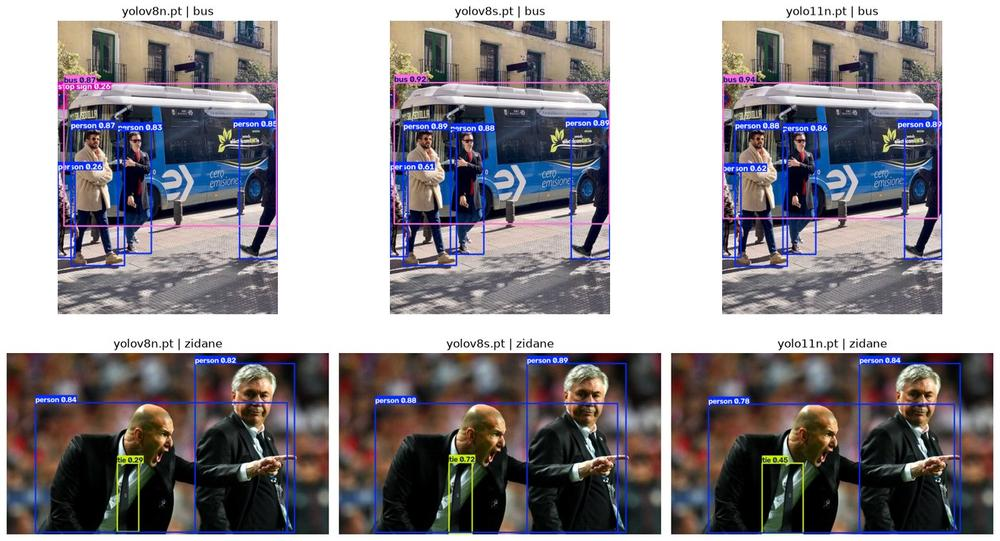

In [44]:
fig, axes = plt.subplots(len(SAMPLES), len(MODELS), figsize=(5 * len(MODELS), 4.5 * len(SAMPLES)))
for i, sname in enumerate(SAMPLES):
    for j, mname in enumerate(MODELS):
        axes[i, j].imshow(vis[(mname, sname)]); axes[i, j].set_title(f"{mname} | {sname}"); axes[i, j].axis("off")
plt.tight_layout(); plt.show()

**실험 1-2 결과 해석**

세 모델을 **같은 조건끼리 두 쌍으로** 비교한다.

| 비교 | 같은 것 | 바뀐 것 | 버스 사진 평균 신뢰도 | zidane 사진 (넥타이 / 평균) |
|---|---|---|---|---|
| v8n → **11n** | 크기 (둘 다 nano) | 버전 | 0.66 → 0.84 | 0.29 → 0.45 / 0.65 → 0.69 |
| v8n → **v8s** | 버전 (둘 다 v8) | 크기 | 0.66 → 0.84 | 0.29 → 0.72 / 0.65 → 0.83 |

- **버전 효과 (nano끼리):** 11n이 v8n보다 더 확신 있게 예측했다. 파라미터도 2.6M으로 v8n(3.2M)보다 작다. 다만 zidane에서는 사람 한 명(0.78)이 v8n(0.82)보다 조금 낮았다.
- **크기 효과 (v8끼리):** v8s가 가장 확신 있게 예측했지만, 파라미터는 v8n의 약 3.5배(11.2M)다.
- **찾은 물체는 거의 같다.** zidane에서는 세 모델 모두 사람 2 + 넥타이 1을 찾았고, 버스 사진에서는 신뢰도 0.26이던 정지 표지판을 v8n만 잡았다. 그래서 이 차이는 **정확도보다는 확신 정도의 차이**다.
- 한 장씩 추론한 시간(10~18ms)은 GPU 준비 시간의 영향이 커서, 이 실험만으로 속도 차이를 말하기는 어렵다.

In [45]:
rows = []
for iou in [0.3, 0.5, 0.7, 0.9]:
    for sname, im in samples.items():
        r = model.predict(im, conf=0.1, iou=iou, device=DEVICE, verbose=False)[0]
        rows.append({"iou(NMS)": iou, "image": sname, "boxes": len(r.boxes)})
pd.DataFrame(rows).pivot(index="iou(NMS)", columns="image", values="boxes")

image,bus,zidane
iou(NMS),,
0.3,6,6
0.5,6,8
0.7,6,12
0.9,9,13


📝 **설명**

**IoU(Intersection over Union)란?** 두 박스가 **얼마나 겹치는지**를 0~1로 나타낸 값이다.
IoU = **겹친 넓이 ÷ 두 박스를 합친 넓이**. 완전히 겹치면 1, 전혀 안 겹치면 0이다.

**NMS(Non-Maximum Suppression, 중복 박스 제거)란?** YOLO는 물체 하나에 박스를 여러 개 겹쳐서 예측한다. NMS는 그중 **하나만 남기는 정리 단계**다.
1. 신뢰도가 가장 높은 박스를 고른다.
2. 그 박스와 **IoU가 기준값(`iou`)보다 큰** 박스는 같은 물체를 중복으로 잡은 것으로 보고 지운다.
3. 남은 박스들로 1~2를 반복한다.

→ `iou` 기준을 **낮추면** 조금만 겹쳐도 지워서 박스가 **적어지고**, **높이면** 많이 겹쳐야 지워서 박스가 **많아진다**.

**실험 1-3 결과 해석**

- **버스 사진**은 IoU 0.3~0.7에서 6개로 그대로였고, 0.9에서야 9개로 늘었다. 사람들이 서로 많이 겹치지 않아서다.
- **zidane 사진**은 0.3 → 6개, 0.5 → 8개, 0.7 → 12개, 0.9 → 13개로 크게 변했다. 같은 사람에게 여러 박스가 겹쳐 나오는데, IoU 기준이 느슨할수록 그 중복 박스가 지워지지 않고 남는다.

→ 제품이 **촘촘히 붙어 있는 라인**에서는 IoU를 너무 낮추면 붙은 제품 두 개가 하나로 합쳐지고, 너무 높이면 한 제품에 박스가 여러 개 생긴다. 기본값 0.7 근처에서 현장 배치에 맞게 조정해야 한다.

---
# Part 2. YOLOv8 학습 실습

#### 데이터셋 다운로드
https://universe.roboflow.com/warisara-kaewsuwan-cf2hs/stamp-bcrhe

- 사용 버전: **v10** (2022-04-02) · YOLOv8 형식 · 클래스 `shoes`, `stamp`
- 분할: train 1,100 / valid 273 / test 193 · 416×416으로 리사이즈됨
- 시나리오: 작업대 위에서 신발에 **도장(stamp)** 이 찍혔는지 위에서 내려다보며 확인하는 제조 공정 영상

In [46]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

📝 **설명** — Part 1에서 쓰던 모델과 별개로, 학습을 시작할 **새 사전학습 모델**을 불러온다. COCO로 이미 학습된 가중치에서 출발하면(전이학습) 적은 데이터로도 빨리 수렴한다.

* `datasets`
    * `stamp`
        * `test`
        * `train`
        * `valid`
        * `data.yaml`

📝 **설명** — 과제와 같은 구조로 `CV-YOLO/datasets/stamp/`에 압축을 풀었다. 노트북이 `CV-YOLO/notebooks/`에 있으므로 과제 코드의 `../datasets/stamp/...` 경로가 그대로 맞는다.
각 split 폴더에는 `images/`(사진)와 `labels/`(사진마다 `클래스 x y w h` 정규화 좌표가 적힌 txt)가 있다.

In [47]:
model.train(
    data="../datasets/stamp/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="stamp_detect",
    device=0
)

Ultralytics 8.4.154  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../datasets/stamp/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stamp_detect, nbs=64, nms

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002B2A4FDAB50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

📝 **설명** — 사전학습 가중치에서 시작해 stamp 데이터로 파인튜닝한다.

| 인자 | 의미 |
|---|---|
| `data` | 데이터 설정 파일. 이미지 경로(`train`/`val`/`test`)와 클래스 이름(`names: ['shoes', 'stamp']`)이 들어 있다 |
| `epochs=20` | 학습 데이터 전체를 20번 반복 |
| `imgsz=640` | 입력 크기. 원본(416×416)을 640으로 키워 넣는다 |
| `batch=16` | 한 번에 16장씩 묶어서 학습 |
| `name` | 결과 폴더 이름 → `runs/detect/stamp_detect` |
| `device=0` | 첫 번째 GPU 사용 |

- 로그 첫 부분의 `Overriding model.yaml nc=80 with nc=2`: COCO 80개 클래스용 출력층을 **2개 클래스용으로 바꿔** 새로 학습한다는 뜻이다.
- 에폭마다 `box_loss`(위치 오차), `cls_loss`(분류 오차), `dfl_loss`(박스 경계 분포 오차)가 줄어드는지, 검증 mAP가 오르는지 본다.
- 마지막에 가장 좋았던 에폭의 가중치를 `weights/best.pt`로 저장하고, 그 가중치로 한 번 더 검증한다.
- 셀의 `Out`은 `model.train()`이 돌려준 평가 객체다. PR 곡선용 숫자까지 모두 출력돼 매우 길다 (PDF에서는 앞뒤만 남겼다).

In [48]:
metrics = model.val()
print("🔍 평가 결과:", metrics)

Ultralytics 8.4.154  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 154.028.4 MB/s, size: 26.6 KB)
val: Scanning C:\Users\LOQ5060\Desktop\CV-YOLO\datasets\stamp\valid\labels.cache... 273 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 273/273  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.9it/s 3.7s
                   all        273        952      0.953      0.987      0.985       0.64
                 shoes        204        408      0.928      0.974      0.975      0.717
                 stamp        273        544      0.978          1      0.995      0.562
Speed: 2.0ms preprocess, 5.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\runs\detect\val
🔍 평가 결과: ultralytics.utils.m

📝 **설명** — 학습이 끝난 모델(`best.pt`)로 **검증 데이터(valid 273장)** 를 다시 평가한다. 학습 때 쓴 `data` 설정을 기억하고 있어서 인자 없이 호출할 수 있다.
로그 표의 `Images`는 해당 클래스가 나온 사진 수, `Instances`는 정답 박스 수다. `print(metrics)`는 객체 전체를 출력하므로 길다 (PDF에서는 앞뒤만 남겼다).

In [49]:
import pandas as pd

data = {
    "Class": ["all", "shoes", "stamp"],
    "Images": [273, 204, 273],
    "Instances": [952, 408, 544],
    "Precision": [0.953, 0.928, 0.978],
    "Recall": [0.987, 0.974, 1.000],
    "mAP@.5": [0.985, 0.975, 0.995],
    "mAP@.5:.95": [0.640, 0.717, 0.562],
}

df = pd.DataFrame(data)

print("### 📊 Evaluation Results Table (Markdown Format)\n")
print(df.to_markdown(index=False))

print("\n### 📝 Explanation of Each Column")
print("""
- **Class**: Object class name. "all" means aggregated results over all classes.
- **Images**: Number of images in which this class appears (or total evaluation images for 'all').
- **Instances**: Total number of ground truth objects for the class.
- **Precision**: Proportion of correct positive predictions (TP / (TP + FP)).
- **Recall**: Proportion of ground truths that were correctly detected (TP / (TP + FN)).
- **mAP@.5**: Mean Average Precision at IoU threshold 0.5.
- **mAP@.5:.95**: mAP averaged over IoU thresholds from 0.5 to 0.95 in steps of 0.05 (more stringent metric).
""")

### 📊 Evaluation Results Table (Markdown Format)

| Class   |   Images |   Instances |   Precision |   Recall |   mAP@.5 |   mAP@.5:.95 |
|:--------|---------:|------------:|------------:|---------:|---------:|-------------:|
| all     |      273 |         952 |       0.953 |    0.987 |    0.985 |        0.64  |
| shoes   |      204 |         408 |       0.928 |    0.974 |    0.975 |        0.717 |
| stamp   |      273 |         544 |       0.978 |    1     |    0.995 |        0.562 |

### 📝 Explanation of Each Column

- **Class**: Object class name. "all" means aggregated results over all classes.
- **Images**: Number of images in which this class appears (or total evaluation images for 'all').
- **Instances**: Total number of ground truth objects for the class.
- **Precision**: Proportion of correct positive predictions (TP / (TP + FP)).
- **Recall**: Proportion of ground truths that were correctly detected (TP / (TP + FN)).
- **mAP@.5**: Mean Average Precision at IoU threshold 0.5.


📝 **설명** — 바로 위 검증 로그의 숫자를 표로 옮겨 정리했다. (과제 코드와 같은 방식이고, 값은 이번 실행 결과로 바꿨다.)

| 지표 | 쉽게 말하면 |
|---|---|
| Precision | 모델이 "있다"고 한 것 중 진짜 비율 → 낮으면 **헛것을 봄(오탐)** |
| Recall | 실제로 있는 것 중 찾아낸 비율 → 낮으면 **놓침(미탐)** |
| mAP@.5 | 박스가 절반 이상만 겹쳐도 정답 → "위치를 대충 맞히나" |
| mAP@.5:.95 | 0.5~0.95로 점점 엄격하게 → "박스를 딱 맞게 치나" |

In [50]:
metrics.box.map, metrics.box.map50, metrics.box.map75, metrics.box.maps

(np.float64(0.6395495664152615),
 np.float64(0.9850004041920235),
 np.float64(0.7395406571714536),
 array([    0.71673,     0.56237]))

📝 **설명** — 표의 값을 코드로 꺼내는 방법. `map`(mAP@.5:.95), `map50`, `map75`(IoU 0.75 기준), `maps`(클래스별 mAP@.5:.95 — shoes, stamp 순).


**평가 결과 해석**

| | Precision | Recall | mAP@.5 | mAP@.5:.95 |
|---|---|---|---|---|
| **이번 실행** (RTX 5060, ultralytics 8.4) — all | 0.953 | 0.987 | 0.985 | 0.640 |
| shoes | 0.928 | 0.974 | 0.975 | **0.717** |
| stamp | 0.978 | **1.000** | **0.995** | **0.562** |
| 과제 예시 (A100, ultralytics 8.3) — all | 0.979 | 0.903 | 0.982 | 0.656 |

- 환경과 라이브러리 버전이 달라도 **mAP@.5 0.98 / mAP@.5:.95 0.64~0.66** 으로 과제 예시와 같은 수준이 재현됐다.
- **stamp**는 mAP@.5가 0.995이고 Recall이 1.000으로 하나도 놓치지 않았다. 그런데 mAP@.5:.95는 0.562로 shoes(0.717)보다 낮다. **작은 도장은 찾기는 잘 찾지만 박스 경계를 정확히 맞추기 어렵다**. mAP75(0.740)가 mAP50(0.985)보다 크게 낮은 것도 같은 이유다.
- **shoes**는 Precision 0.928로, 없는 곳을 신발로 잡는 오탐이 도장보다 많다.

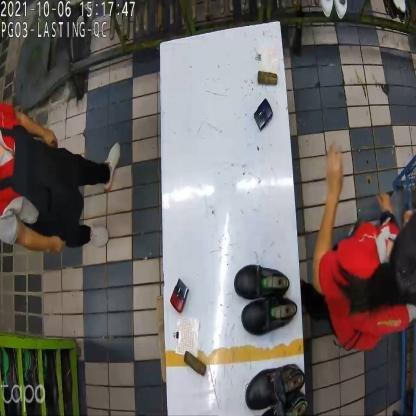

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open('../datasets/stamp/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg')

image

In [52]:
results = model.predict('../datasets/stamp/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg')
results[0].save(filename='predicted1.jpg')


image 1/1 C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\..\datasets\stamp\test\images\clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg: 640x640 2 shoess, 2 stamps, 14.5ms
Speed: 2.4ms preprocess, 14.5ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


'predicted1.jpg'

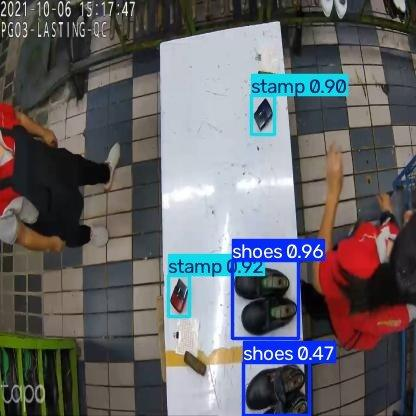

In [53]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("predicted1.jpg")

image

In [54]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 1., 1., 0.], device='cuda:0')
conf: tensor([0.9577, 0.9223, 0.8993, 0.4741], device='cuda:0')
data: tensor([[232.5940, 260.6025, 298.7854, 338.3451,   0.9577,   0.0000],
        [168.5933, 275.5515, 189.8084, 316.0340,   0.9223,   1.0000],
        [251.9562,  95.4230, 274.1241, 134.1069,   0.8993,   1.0000],
        [243.2766, 362.1186, 309.7711, 415.9079,   0.4741,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (416, 416)
shape: torch.Size([4, 6])
xywh: tensor([[265.6897, 299.4738,  66.1914,  77.7425],
        [179.2008, 295.7927,  21.2151,  40.4825],
        [263.0402, 114.7650,  22.1678,  38.6839],
        [276.5239, 389.0132,  66.4945,  53.7892]], device='cuda:0')
xywhn: tensor([[0.6387, 0.7199, 0.1591, 0.1869],
        [0.4308, 0.7110, 0.0510, 0.0973],
        [0.6323, 0.2759, 0.0533, 0.0930],
        [0.6647, 0.9351, 0.1598, 0.1293]], device='cuda:0')
xyxy: tensor([[232.5940, 260.6025, 2

📝 **설명** — 학습에 쓰지 않은 **test 이미지**로 예측했다. `results[0].save()`는 박스를 그린 이미지를 파일로 저장한다.
`boxes`의 `cls`가 이제 0(shoes)과 1(stamp)뿐이다 → COCO 80개 클래스 모델이 우리 시나리오 전용 모델로 바뀌었다.

- 과제 예시와 같은 test 사진에서 **shoes 2개(0.96, 0.47) + stamp 2개(0.92, 0.90)** 를 찾았다. 과제 예시는 shoes 1 + stamp 2였다.
- 추가로 잡힌 신발(0.47)은 박스 좌표(y 362~416)를 보면 **이미지 아래 가장자리에 잘려 보이는 신발**이다. 신뢰도가 0.5 미만이라, 임계값을 0.5로 올리면 과제 예시와 같은 결과가 된다.

---
## 🔬 개인 실험 2 — 새 모델과 신뢰도 조절로 성능이 좋아질까?

| 실험 | 해본 것 |
|---|---|
| 2-1 | 다른 모델(**YOLO11n**)·큰 모델(YOLOv8s)·긴 학습(50 에폭)과 비교 |
| 2-2 | 신뢰도 기준값 최적화 |

비교는 학습에 쓰지 않은 **test 셋(193장)** 으로 한다.

### 2-1. 모델 비교
**가설:** 최신 모델이나 큰 모델로 바꾸면, 또는 더 오래 학습하면 성능이 오를 것이다.

(첫 셀은 경로와 데이터 설정을 준비하는 셀이다.)

In [55]:
import shutil

ROOT = Path.cwd().parent
STAMP = ROOT / "datasets" / "stamp"
RUNS = ROOT / "runs" / "stamp"                  # 비교 실험 결과 저장 위치
BASE_RUN = Path(model.trainer.save_dir)         # 위에서 학습한 기본 모델(stamp_detect) 폴더
print("기본 학습 결과 폴더:", BASE_RUN)

# 실험용 데이터 설정: 절대경로로 고정해 어디서 실행해도 같은 데이터를 쓰게 한다
cfg = yaml.safe_load((STAMP / "data.yaml").read_text(encoding="utf-8"))
DATA = STAMP / "data_local.yaml"
DATA.write_text(yaml.safe_dump({"path": STAMP.as_posix(), "train": "train/images", "val": "valid/images",
                                "test": "test/images", "names": cfg["names"]}, allow_unicode=True), encoding="utf-8")

기본 학습 결과 폴더: C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\runs\detect\stamp_detect


133

In [56]:
EXPS = [("stamp_detect", BASE_RUN, "yolov8n.pt", 20),          # 위에서 학습한 기본 모델
        ("v8n_e50", RUNS / "v8n_e50", "yolov8n.pt", 50),
        ("11n_e20", RUNS / "11n_e20", "yolo11n.pt", 20),
        ("v8s_e20", RUNS / "v8s_e20", "yolov8s.pt", 20)]
RUN_DIR = {name: run for name, run, _, _ in EXPS}
summary = []
for name, run, weights, ep in EXPS:
    if not (run / "weights" / "best.pt").exists():   # 이미 학습한 실험은 결과 재사용
        YOLO(weights).train(data=str(DATA), epochs=ep, imgsz=640, batch=16, device=DEVICE,
                            project=str(RUNS), name=name, exist_ok=True, workers=2, seed=42, verbose=False)
    m = YOLO(str(run / "weights" / "best.pt"))
    v = m.val(data=str(DATA), split="test", device=DEVICE, verbose=False, plots=False,
              project=str(RUNS), name=f"{name}_test", exist_ok=True)
    res = pd.read_csv(run / "results.csv")
    summary.append({"exp": name, "model": weights, "epochs": ep, "best_epoch": int(res.loc[res["metrics/mAP50-95(B)"].idxmax(), "epoch"]),
                    "params(M)": round(sum(p.numel() for p in m.model.parameters()) / 1e6, 2),
                    "P": v.box.mp, "R": v.box.mr, "mAP50": v.box.map50, "mAP50-95": v.box.map,
                    "shoes mAP50-95": v.box.maps[0], "stamp mAP50-95": v.box.maps[1],
                    "infer_ms": v.speed["inference"]})
exp_df = pd.DataFrame(summary).round(3)
(ROOT / "results").mkdir(exist_ok=True)
exp_df.to_csv(ROOT / "results" / "stamp_experiments.csv", index=False)
exp_df

Ultralytics 8.4.154  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.40.3 ms, read: 23.72.9 MB/s, size: 27.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\LOQ5060\Desktop\CV-YOLO\datasets\stamp\test\labels... 193 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 193/193 1.5Kit/s 0.1s
val: New cache created: C:\Users\LOQ5060\Desktop\CV-YOLO\datasets\stamp\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 6.8it/s 1.9s
                   all        193        633      0.951      0.985      0.985      0.627
Speed: 1.5ms preprocess, 4.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Ultralytics 8.4.154  Python-3.11.9 torch

,exp,model,epochs,best_epoch,params(M),P,R,mAP50,mAP50-95,shoes mAP50-95,stamp mAP50-95,infer_ms
0,stamp_detect,yolov8n.pt,20,16,3.01,0.951,0.985,0.985,0.627,0.696,0.558,4.815
1,v8n_e50,yolov8n.pt,50,36,3.01,0.982,0.920,0.979,0.626,0.700,0.553,2.890
2,11n_e20,yolo11n.pt,20,16,2.59,0.975,0.931,0.982,0.634,0.692,0.576,7.056
3,v8s_e20,yolov8s.pt,20,7,11.14,0.962,0.939,0.975,0.628,0.693,0.564,6.568


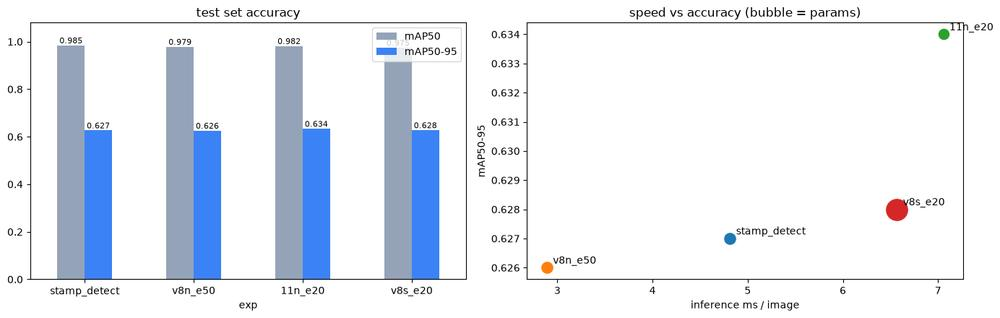

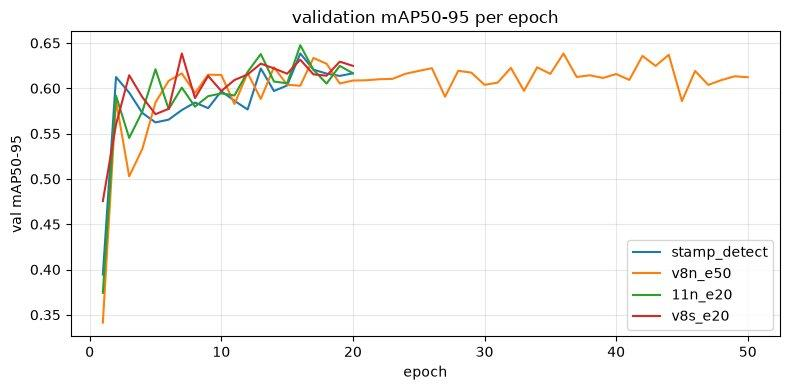

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
exp_df.plot.bar(x="exp", y=["mAP50", "mAP50-95"], rot=0, ax=axes[0], color=["#94a3b8", "#3b82f6"])
axes[0].set_ylim(0, 1.08); axes[0].set_title("test set accuracy")
for c in axes[0].containers: axes[0].bar_label(c, fmt="%.3f", fontsize=8)
for _, r in exp_df.iterrows():
    axes[1].scatter(r["infer_ms"], r["mAP50-95"], s=r["params(M)"] * 40)
    axes[1].annotate(r["exp"], (r["infer_ms"], r["mAP50-95"]), textcoords="offset points", xytext=(6, 4))
axes[1].set_xlabel("inference ms / image"); axes[1].set_ylabel("mAP50-95"); axes[1].set_title("speed vs accuracy (bubble = params)")
plt.tight_layout(); plt.savefig(ROOT / "report" / "images" / "stamp_experiments.png", dpi=150); plt.show()

# 에폭별 검증 mAP 곡선
plt.figure(figsize=(8, 4))
for name, run, _, _ in EXPS:
    res = pd.read_csv(run / "results.csv")
    plt.plot(res["epoch"], res["metrics/mAP50-95(B)"], label=name)
plt.xlabel("epoch"); plt.ylabel("val mAP50-95"); plt.legend(); plt.title("validation mAP50-95 per epoch"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(ROOT / "report" / "images" / "stamp_epoch_curves.png", dpi=150); plt.show()

**실험 2-1 결과 해석**

**결과** (test 193장)
| 모델 | 비교 | mAP50 | mAP50-95 | 파라미터 |
|---|---|---|---|---|
| YOLOv8n · 20에폭 | 기준 | 0.985 | 0.627 | 3.0M |
| YOLO11n · 20에폭 | **버전** (nano끼리) | 0.982 | **0.634** (+0.007) | 2.6M |
| YOLOv8s · 20에폭 | **크기** (v8끼리) | 0.975 | 0.628 (+0.001) | 11.1M |
| YOLOv8n · 50에폭 | **학습 길이** | 0.979 | 0.626 (−0.001) | 3.0M |

**해석**
- **버전 (v8n → 11n):** 11n이 **조금 우수**하고 더 가볍다. 다만 차이(+0.007)는 같은 모델을 다시 학습할 때 생기는 흔들림(±0.01) 수준이라, 크게 좋아졌다고 보기는 어렵다.
- **크기 (v8n → v8s):** 모델이 3.7배 커졌는데 성능은 같다.
- **학습 길이 (20 → 50에폭):** 더 오래 학습해도 같다.

→ 가볍고 점수가 가장 높은 **YOLO11n**을 2-2에 사용했다.

**왜 차이가 없을까?**
- 이미 대부분 잘 찾고 있다(mAP50 0.98). 더 오를 여지가 적다.
- 틀리는 건 이미지 가장자리에 잘린 신발, 손에 든 신발처럼 학습 데이터에 드문 장면이다. 모델을 바꿔도 거의 본 적 없는 장면은 잘 못 찾는다.
- 학습 사진이 거의 영상 2개에서 뽑은 비슷한 장면이라, 작은 모델로도 충분히 배운다.

→ 성능을 올리려면 모델보다 **데이터**(드문 장면 사진 추가)를 바꿔야 한다.

### 2-2. 신뢰도 최적화
**가설:** 기본값 0.25 대신 이 데이터에 맞는 신뢰도를 고르면 더 좋아질 것이다.

valid 셋에서 F1(정밀도와 재현율의 균형 점수)이 가장 높은 신뢰도를 고르고, test 셋에서 기본값 0.25와 비교한다.

가장 좋은 모델: 11n_e20
valid 셋 기준 최적 신뢰도: 0.55 (F1 0.951)


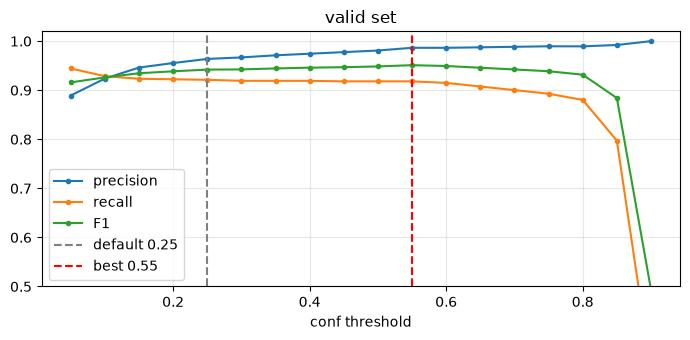

,conf,precision,recall,F1,개수 틀린 사진
기본값,0.25,0.961,0.946,0.954,46
최적값,0.55,0.980,0.935,0.957,46


In [58]:
best_name = exp_df.sort_values("mAP50-95", ascending=False).iloc[0]["exp"]
best_model = YOLO(str(RUN_DIR[best_name] / "weights" / "best.pt"))     # 2-1에서 가장 좋았던 모델로 진행
print("가장 좋은 모델:", best_name)

from ultralytics.utils.metrics import box_iou

def collect(model, split):
    """사진마다 정답 박스와 예측 박스(신뢰도 0.01 이상 전부)를 모아 둔다."""
    recs = []
    for r in model.predict(str(STAMP / split / "images"), conf=0.01, device=DEVICE, stream=True, verbose=False):
        h, w = r.orig_shape
        rows = [list(map(float, l.split())) for l in (STAMP / split / "labels" / (Path(r.path).stem + ".txt")).read_text().splitlines() if l.strip()]
        gt = torch.tensor([[(cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h] for _, cx, cy, bw, bh in rows]).reshape(-1, 4)
        recs.append((torch.tensor([int(r[0]) for r in rows]), gt, r.boxes.cls.cpu(), r.boxes.xyxy.cpu(), r.boxes.conf.cpu()))
    return recs

def score(recs, conf):
    """신뢰도 conf 이상 박스만 남겼을 때의 정밀도·재현율·F1, 개수가 틀린 사진 수"""
    tp = fp = fn = wrong = 0
    for gc, gb, pc, pb, pf in recs:
        keep = pf >= conf
        pc, pb, pf = pc[keep], pb[keep], pf[keep]
        used = set()
        for i in pf.argsort(descending=True).tolist():          # 신뢰도 높은 박스부터 정답과 짝짓기
            ious = box_iou(pb[i:i + 1], gb)[0] if len(gb) else torch.tensor([])
            cand = [(float(ious[j]), j) for j in range(len(gb)) if j not in used and gc[j] == pc[i] and ious[j] >= 0.5]
            if cand:
                used.add(max(cand)[1]); tp += 1
            else:
                fp += 1
        fn += len(gb) - len(used)
        wrong += any((pc == k).sum() != (gc == k).sum() for k in (0, 1))
    p, r = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
    return {"conf": conf, "precision": p, "recall": r, "F1": 2 * p * r / max(p + r, 1e-9), "개수 틀린 사진": wrong}

# 1) valid 셋에서 최적 신뢰도 찾기
val_recs = collect(best_model, "valid")
val_sweep = pd.DataFrame([score(val_recs, c) for c in np.round(np.arange(0.05, 0.95, 0.05), 2)])
best_conf = float(val_sweep.loc[val_sweep["F1"].idxmax(), "conf"])
print(f"valid 셋 기준 최적 신뢰도: {best_conf} (F1 {val_sweep['F1'].max():.3f})")

plt.figure(figsize=(7, 3.5))
for col in ["precision", "recall", "F1"]:
    plt.plot(val_sweep.conf, val_sweep[col], "o-", ms=3, label=col)
plt.axvline(0.25, color="gray", ls="--", label="default 0.25"); plt.axvline(best_conf, color="red", ls="--", label=f"best {best_conf}")
plt.xlabel("conf threshold"); plt.ylim(0.5, 1.02); plt.grid(alpha=.3); plt.legend(); plt.title("valid set")
plt.tight_layout(); plt.savefig(ROOT / "report" / "images" / "stamp_conf_opt.png", dpi=150); plt.show()

# 2) test 셋에서 기본값과 비교
test_recs = collect(best_model, "test")
conf_cmp = pd.DataFrame([score(test_recs, 0.25), score(test_recs, best_conf)], index=["기본값", "최적값"]).round(3)
conf_cmp

**실험 2-2 결과 해석**

**결과**
| | 신뢰도 | 정밀도 | 재현율 | F1 | 개수 틀린 사진 |
|---|---|---|---|---|---|
| 기본값 | 0.25 | 0.961 | 0.946 | 0.954 | 46 / 193 |
| 최적값 | **0.55** | **0.980** | 0.935 | **0.957** | 46 / 193 |

**해석:** 신뢰도를 0.55로 올리니 **헛것(오탐)이 줄어 정밀도가 0.98로 올랐지만**, 맞던 것도 조금 빠져서 전체 점수(F1)는 거의 그대로였다.

**왜 효과가 작을까?**
- 헛것이 원래 적어서(24개) 걸러내도 점수가 크게 바뀌지 않는다.
- 틀린 사진 46장 중 29장은 신발 1개를 놓친 경우인데, 모델이 이 신발을 낮은 신뢰도로만 잡는다. 기준을 낮추면 헛것이 늘어나서 신뢰도 조절로는 고칠 수 없다.

→ 오탐을 줄이고 싶을 때는 신뢰도를 올리는 게 도움이 되지만(정밀도 0.98), 성능을 크게 올리는 방법은 아니다.

---
# 목표 기준 평가 및 성과
| 목표 | 수행 내용 | 결과 |
|---|---|---|
| ① 추론 결과 구조 이해 | `Results`/`Boxes` 구조, xywh·xyxy·정규화 좌표를 **직접 계산해 검증**, 클래스 필터링, crop | 직접 계산한 값과 `xywhn`/`xyxyn`이 일치함을 확인 |
| ② 제조 데이터 학습·평가 | stamp v10으로 YOLOv8n 20 에폭 파인튜닝 (과제 코드 그대로) | val **mAP@.5 0.985 / mAP@.5:.95 0.640** (과제 예시 0.982 / 0.656과 같은 수준) |
| ③ 성능 범위 실험 | 신뢰도·NMS·추가 샘플·모델 3종(**YOLO11n** 포함)·에폭·신뢰도 최적화 | 모델·에폭·신뢰도보다 **데이터(가장자리·손에 든 신발 같은 드문 장면)** 가 성능을 결정함 |
| (추가) 레포 리팩터링 | 노트북 흐름을 `src/`·`tools/` 스크립트로 분리, README 작성, 제출용 PDF 자동 생성 | https://github.com/hwang-ye-song/CV_YOLO |

**성과 요약**
- 20 에폭(약 3.5분)의 가벼운 학습만으로 검증 셋의 도장 **Recall 1.000**. "도장이 찍혔는지"를 확인하는 공정 목적에는 충분한 수준이다.
- 다른 모델(YOLO11n)을 적용해 더 작은 모델로 같거나 조금 나은 성능(test mAP50-95 0.634)을 얻었다.
- 약점은 **가장자리·손에 든 신발을 놓치는 것**이고, 모델이나 신뢰도가 아니라 **데이터 보강**으로 풀어야 한다는 것을 실험으로 확인했다.

# 개인 회고
### 진행하면서 막혔던 부분과 해결
| 막힌 부분 | 원인 | 해결 |
|---|---|---|
| Roboflow 링크로 받은 데이터가 이미지 3장뿐 | 공유 링크가 다른 버전(v2, `stamp` 1개 클래스)이었다 | 데이터셋 버전 8개의 분할 수를 비교해, 과제와 같은 **v10**(train 1,100 / valid 273 / test 193)을 찾아 다시 받았다 |
| 명령줄로 받은 zip이 HTML 파일 | `universe.roboflow.com` 링크가 보안 확인 페이지를 돌려줬다 | Roboflow 안내 형식인 `app.roboflow.com/ds/...` 주소로 받았다 |
| RTX 5060에 맞는 PyTorch 필요 | RTX 50 시리즈는 CUDA 12.8 빌드가 필요하다 | `--index-url .../cu128`로 PyTorch를 설치했다 |
| 과제 코드 `import requests=` 오류 | 문법 오류(오타) | `import requests`로 고쳤다 |
| 과제의 `./runs/detect/predict/bus.jpg`를 못 찾음 | 결과가 홈 폴더(`C:\Users\...\runs`)에 저장되고 있었다 | 이 프로젝트 커널에만 YOLO 설정 폴더를 따로 지정해, 결과가 노트북 폴더의 `runs/`에 저장되게 했다 |
| `data.yaml`의 `../train/images` 상대경로 | 실행 위치에 따라 경로가 달라진다 | 데이터셋을 과제와 같은 `../datasets/stamp` 위치에 두었다. 개인 실험용으로는 절대경로 yaml을 따로 만들었다 |
| PDF에 숫자 수천 개가 수십 쪽 찍힘 | `model.train()` 반환값과 `print(metrics)`가 곡선 데이터까지 모두 출력했다 | 노트북은 과제 코드 그대로 두고, PDF로 바꿀 때 긴 출력은 앞뒤만 남기게 했다 |
| 다시 학습하니 결과 숫자가 달라짐 | GPU 학습은 시드를 고정해도 실행마다 조금씩 달라진다 (mAP50-95 ±0.01) | 해석을 최종 실행 결과에 맞춰 다시 썼고, 모델 비교는 이 흔들림 폭을 고려해 판단했다 |
| 노트북 결과가 덮어써질 뻔함 | 실행 전 버전이 열린 JupyterLab 탭이 자동 저장했다 | 백그라운드 실행 중에는 Jupyter 서버를 종료해 같은 노트북이 열려 있지 않게 했다 |

### KPT
- **Keep**
  - **AI를 활용해 실습을 진행한 것.** 막히는 부분이 있어도 AI에게 원인을 묻고 고치게 하니 바로바로 해결돼서 실습 진행에 어려움이 없었다. 다음에도 이 방식으로 진행할 것 같다.
  - **YOLO의 기본 조작을 이해했다.** 신뢰도를 조절하는 방법, 결과물(클래스 번호, xywh·xyxy 좌표)을 해석하는 방법을 직접 해보며 익혔다.
  - **신뢰도는 목적에 맞게 쓰는 손잡이라는 것을 알았다.** 신뢰도를 바꿔 가며 박스가 몇 개 생기는지 확인해 보니, 오탐 비용이 큰 작업에서는 신뢰도를 높이고, 하나라도 발견하는 것이 중요한 작업에서는 신뢰도를 낮춰서 목적에 맞게 쓰면 된다.
- **Problem**
  - **처음에는 원리를 이해하는 데 매달렸다.** 수업을 진행하다 보니 원리보다 **사용 방법과 어디에 쓰는지**를 아는 것이 더 중요하다는 것을 깨달았다. 그래서 AI를 활용해 "내가 정한 가상의 목적에 맞게 작동하는 모델을 만들려면 어떻게 해야 하는가"를 생각해 보는 방식으로 바꿨다.
    - 예: 제조업에서는 목표 정확도를 얼마로 잡아야 할까? → 잘못 판정하면 비용이 크니 **정확도 90% 이상**, 또는 논문을 참고해 **사람 검사자와 같거나 그 이상**을 목표로 하는 것이 좋겠다. 이 기준으로 보면 이번 모델은 도장은 거의 다 찾지만(검증 재현율 1.000), 신발은 가장자리·손에 든 신발을 자주 놓쳐 아직 부족하다.
  - **큰 모델로 바꿔도 성능이 거의 오르지 않은 것이 의외였다.** 대신 큰 모델·최신 모델은 확신도가 높아졌다(개인 실험 1: 평균 확신도 v8n 0.66 → v8s·11n 0.84). 그래서 될 수 있으면 **최신 모델을 쓰고 신뢰도를 올리는 것**이 더 좋겠다고 생각했다(개인 실험 2-2: YOLO11n + 신뢰도 0.55에서 정밀도 0.98).
- **Try**
  - **YOLO로 틀린그림 찾기 도구를 만들어 보고 싶다.** 두 그림에서 다른 곳에 박스를 치는 것은, 정상 제품과 다른 부분을 찾아내는 **불량 영역 탐지**와 원리가 같다. 재미있는 주제로 먼저 해보고, 직접 찍은 제품 사진의 정상/불량 탐지로 이어가 볼 생각이다.

### AAR (After Action Review)
| 질문 | 답 |
|---|---|
| 원래 의도한 것은? | 솔직히 큰 기대 없이 시작했다. |
| 실제로 일어난 일은? | "목적에 따라 어디에 쓸 수 있는지 공부하라"는 안내대로 해보니, 틀린그림 찾기 도구 같은 나름 재미있는 발상까지 이어졌고 과제가 재미있어졌다. |
| 무엇을 얻었나? | ① YOLO 기본 사용법과 목적에 맞게 쓰는 방법 ② 기존 공부 방법에 더해, **문제를 파악하고 해결하기 위해 공부하는 방법** |
| 현장에 쓴다면 먼저 보완할 점은? | ① **가장자리와 손에 든 신발을 놓치는 문제**부터 해결해야 한다(남은 오류 46장 중 29장이 "신발 1개 놓침"). ② 하드웨어로는 **일정 시간마다 렌즈를 닦아 주는 장치**를 달아 먼지로 생기는 흐림을 막고, 노이즈는 주로 어두운 조명에서 생기므로 **조명을 보강**한다. |

### 동료 피드백 (선택)
- 받은 피드백 없음